## Imports

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    dtw, 
    format_stats, 
    mean_center, 
    show_source
)

## Functions

In [ ]:
show_source(dtw)

In [6]:
def lcss(A, B, epsilon, metric='cosine'):
    """
    Order-preserving longest common subsequence within epsilon distance.
    
    Returns matched fraction in [0,1] (normalized by the shorter sequence).
    """
    close = cdist(A, B, metric=metric) < epsilon
    n, m = close.shape
    L = np.zeros((n + 1, m + 1), dtype=int)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if close[i - 1, j - 1]:
                L[i, j] = L[i - 1, j - 1] + 1
            else:
                L[i, j] = max(L[i - 1, j], L[i, j - 1])
    
    return L[n, m] / min(n, m)

In [4]:
show_source(mean_center)

In [151]:
show_source(format_stats)

## Load data

In [8]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [9]:
ep_events_centered = atlep1.events - atlep1.events.mean(axis=0)

# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

## Is delayed recall more similar to own immediate recall than to episode?

In [54]:
warp_dists_imm = []
warp_dists_episode = []

for imm_events, del_events in zip(imm_events_centered, del_events_centered):
    dist_imm = dtw(del_events, imm_events)[0]
    dist_ep = dtw(del_events, ep_events_centered)[0]
    warp_dists_imm.append(dist_imm)
    warp_dists_episode.append(dist_ep)
    
T, p = wilcoxon(warp_dists_imm, warp_dists_episode)
T, p = T.item(), p.item()
print(f'mean immediate-alignment cost: {np.mean(warp_dists_imm):.4f}')
print(f'mean episode-alignment cost: {np.mean(warp_dists_episode):.4f}')
print(f'{T=}, {p=:.4e}')

mean immediate-alignment cost: 0.5321
mean episode-alignment cost: 0.6539
T=1.0, p=2.5274e-10


In [160]:
df = pd.DataFrame(columns=('Comparison', 'participant', 'Warp distance'))
df['Comparison'] = np.repeat(['delayed-->immediate', 'delayed-->episode'], len(participants))
df['participant'] = np.tile(np.arange(1, len(participants) + 1), 2)
df['Warp distance'] = np.concatenate((warp_dists_imm, warp_dists_episode))

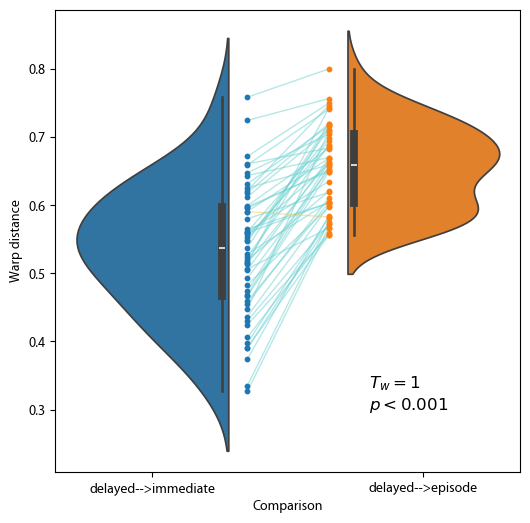

In [166]:
fig, ax = plt.subplots(1, figsize=(6, 6))
ax = sns.violinplot(df, x='Comparison', y='Warp distance', hue='Comparison', split=True, gap=0.3)
inner_boxplot_xshift = 0.01
for line in ax.lines:
    xdata = line.get_xdata()
    center = np.mean(xdata)
    direction = -1 if center < 0.5 else 1  # left vs right violin
    line.set_xdata([x + direction * inner_boxplot_xshift for x in xdata])


scatter_point_size = 10
scatter_x_offset = 0.35
connection_linewidth = 1
connection_alpha = 0.5
decrease_color = '#f9c74f'
increase_color = '#6cd0d0'
no_change_color = 'grey'

imm_scatter_xcoords = np.zeros(len(warp_dists_imm)) + scatter_x_offset
ep_scatter_xcoords = np.ones(len(warp_dists_episode)) - scatter_x_offset

ax.scatter(imm_scatter_xcoords, 
           warp_dists_imm, 
           s=scatter_point_size, 
           zorder=2)
ax.scatter(ep_scatter_xcoords, 
           warp_dists_episode, 
           s=scatter_point_size, 
           zorder=2)
ax.plot([imm_scatter_xcoords, ep_scatter_xcoords], 
        [warp_dists_imm, warp_dists_episode], 
        c=no_change_color, 
        alpha=connection_alpha, 
        lw=connection_linewidth, 
        zorder=1)

for connection_line in ax.get_lines()[-len(participants):]:
    y_imm, y_ep = connection_line.get_ydata()
    if y_imm > y_ep:
        connection_line.set_color(decrease_color)
    elif y_imm < y_ep:
        connection_line.set_color(increase_color)

T, p = wilcoxon(warp_dists_imm, warp_dists_episode)
stat_text =  format_stats(T, p, 'T_w', n_decimals_stat=0)
ax.text(0.8, 0.3, stat_text, fontsize='large')
plt.show()

In [1]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant


def mean_center(*to_center, equal_weight=True):
    """
    Mean-center one or more feature matrices by their shared centroid.

    Returns a tuple of inputs with the same shape & order as passed.
    """
    if len(to_center) == 1:
        return to_center[0] - to_center[0].mean(axis=0)

    input_was_1d = [x.ndim == 1 for x in to_center]
    to_center = [np.atleast_2d(x) for x in to_center]
    if equal_weight:
        mean_centroid = np.mean([x.mean(axis=0) for x in to_center], axis=0)
        centered = [x - mean_centroid for x in to_center]
    else:
        split_inds = np.cumsum([x.shape[0] for x in to_center])[:-1]
        stacked = np.vstack(to_center)
        stacked = stacked - stacked.mean(axis=0)
        centered = np.vsplit(stacked, split_inds)

    return tuple(c[0] if was_1d else c for c, was_1d in zip(centered, input_was_1d))


def dtw(A, B):
    """Monotonic DTW. Returns (avg cost along path, path)."""
    C = cdist(A, B, metric='cosine')
    n, m = C.shape
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            D[i, j] = C[i - 1,j - 1] + min(D[i - 1, j - 1], D[i - 1, j], D[i, j - 1])
    i, j, path = n, m, []
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        mv = min(D[i - 1, j - 1], D[i - 1, j], D[i, j - 1])
        if D[i - 1,j - 1] == mv: 
            i, j = i - 1, j - 1
        elif D[i - 1, j] == mv: 
            i = i - 1
        else:
            j = j - 1
    return D[n, m] / len(path), path[::-1]



atlep1 = Episode('atlep1')
participants = Participant.load_all()


# mean-center episode events
episode_events_centered = atlep1.events - atlep1.events.mean(axis=0)

# mean-center each participant's immediate & delayed recalls by shared mean centroid
events_immediate_centered = {}
events_delayed_centered = {}
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    events_immediate_centered[f'P{p.sub_n}'] = imm_centered
    events_delayed_centered[f'P{p.sub_n}'] = del_centered


# analysis 1: own-immediate vs episode
d_self = np.array([dtw(events_delayed_centered[f'P{p.sub_n}'], 
                       events_immediate_centered[f'P{p.sub_n}'])[0] 
                   for p in participants])
d_epi  = np.array([dtw(events_delayed_centered[f'P{p.sub_n}'], 
                       episode_events_centered)[0] 
                   for p in participants])
print(f'mean of d_self: {d_self.mean():.3f}')
print(f'mean of d_epi: {d_epi.mean():.3f}')
print("self vs episode:", wilcoxon(d_self, d_epi))

# analysis 2: own-immediate vs OTHER participants' immediate recalls
own_beats_other = []
for p in participants:
    dp = {
        f'P{q.sub_n}': dtw(events_delayed_centered[f'P{p.sub_n}'], 
                           events_immediate_centered[f'P{q.sub_n}'])[0] 
        for q in participants
    }
    others = np.array([dp[f'P{q.sub_n}'] for q in participants if q.sub_n != p.sub_n])
    own_beats_other.append(np.mean(dp[f'P{p.sub_n}'] < others))
own_beats_other = np.array(own_beats_other)
print(f'\nmean of own_beats_other: {own_beats_other.mean():.3f}')
print("own-immediate vs others (vs chance 0.5):", wilcoxon(own_beats_other - 0.5))

mean of d_self: 0.532
mean of d_epi: 0.654
self vs episode: WilcoxonResult(statistic=np.float64(1.0), pvalue=np.float64(2.527405387731799e-10))

mean of own_beats_other: 0.971
own-immediate vs others (vs chance 0.5): WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(4.364428137477024e-11))


In [3]:
centroids = []
for i, p in enumerate(participants):
    for rectype in ('atlep1', 'delayed'):
        centroids.append(p.events[rectype].mean(axis=0))
mean_centroid = np.mean(centroids, axis=0)

events_immediate_centered = {}
events_delayed_centered = {}
for p in participants:
    events_immediate_centered[f'P{p.sub_n}'] = p.events['atlep1'] - mean_centroid
    events_delayed_centered[f'P{p.sub_n}'] = p.events['delayed'] - mean_centroid

own_beats_other = []
for p in participants:
    dp = {
        f'P{q.sub_n}': dtw(events_delayed_centered[f'P{p.sub_n}'], 
                           events_immediate_centered[f'P{q.sub_n}'])[0] 
        for q in participants
    }
    others = np.array([dp[f'P{q.sub_n}'] for q in participants if q.sub_n != p.sub_n])
    own_beats_other.append(np.mean(dp[f'P{p.sub_n}'] < others))
own_beats_other = np.array(own_beats_other)
print(f'\nmean of own_beats_other: {own_beats_other.mean():.3f}')
print("own-immediate vs others (vs chance 0.5):", wilcoxon(own_beats_other - 0.5))


mean of own_beats_other: 0.999
own-immediate vs others (vs chance 0.5): WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.2506343175088189e-12))


Text(0.5, 0, "Percentile rank of own immediate recall's similariy vs others'")

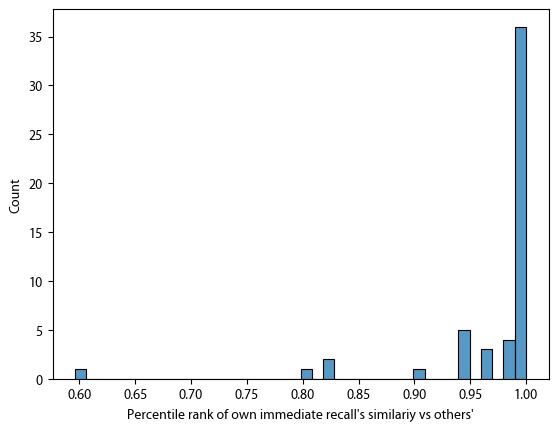

In [31]:
ax = sns.histplot(own_beats_other)
ax.set_xlabel('Percentile rank of own immediate recall\'s similariy vs others\'')

In [7]:
from tqdm.notebook import tqdm


N_PERM = 500                         # order-null draws; lower for speed, raise for stability
rng = np.random.default_rng(0)       # seeded for reproducibility


def dtw_order_z(A, B, n_perm=N_PERM, rng=rng):
    """
    Mean-DTW cost plus its z-score against an order-permutation null.

    The null repeatedly shuffles the *event order* of B while holding B's
    multiset of event vectors (its content) fixed, recomputing the DTW cost
    each time. Subtracting the null mean cancels every order-INVARIANT
    contribution -- the cross-domain offset (episode arm), person-specific
    style (across-participant arm), and raw content/omission overlap -- so the
    z isolates how much B's TRUE ordering lowers the cost relative to A's.

    Returns (observed_cost, z). z << 0  => true order aligns far better than
    random order (shared sequential structure). z ~ 0 => the cost is explained
    by order-invariant content/offset alone.
    """
    observed = dtw(A, B)[0]
    m = B.shape[0]
    null = np.array([dtw(A, B[rng.permutation(m)])[0] for _ in range(n_perm)])
    z = (observed - null.mean()) / (null.std() + 1e-8)
    return observed, z


# ---- Analysis 1: delayed vs own-immediate vs episode -------------------------
obs_self, z_self, obs_epi, z_epi = [], [], [], []
for p in tqdm(participants, leave=False):
    D = events_delayed_centered[f'P{p.sub_n}']
    o, z = dtw_order_z(D, events_immediate_centered[f'P{p.sub_n}'])
    obs_self.append(o); z_self.append(z)
    o, z = dtw_order_z(D, episode_events_centered)
    obs_epi.append(o); z_epi.append(z)
obs_self, z_self, obs_epi, z_epi = map(np.array, (obs_self, z_self, obs_epi, z_epi))

print("=== Analysis 1: delayed vs own-immediate vs episode ===")
print("holistic (raw mean-DTW cost):")
print(f"  mean d_self={obs_self.mean():.3f}  mean d_epi={obs_epi.mean():.3f}")
print("  ", wilcoxon(obs_self, obs_epi))
print("order-isolated (order-permutation z):")
print(f"  mean z_self={z_self.mean():.3f}  mean z_epi={z_epi.mean():.3f}")
print("  ", wilcoxon(z_self, z_epi))


# ---- Analysis 2: delayed vs own- vs others'-immediate ------------------------
own_beats_other, own_beats_other_z = [], []
for p in tqdm(participants, leave=False):
    D = events_delayed_centered[f'P{p.sub_n}']
    obs_by_q, z_by_q = {}, {}
    for q in participants:
        obs_by_q[q.sub_n], z_by_q[q.sub_n] = dtw_order_z(
            D, events_immediate_centered[f'P{q.sub_n}']
        )
    others_o = np.array([obs_by_q[q.sub_n] for q in participants if q.sub_n != p.sub_n])
    others_z = np.array([z_by_q[q.sub_n]  for q in participants if q.sub_n != p.sub_n])
    own_beats_other.append(np.mean(obs_by_q[p.sub_n] < others_o))     # lower cost = more similar
    own_beats_other_z.append(np.mean(z_by_q[p.sub_n] < others_z))     # lower z   = more order-similar
own_beats_other   = np.array(own_beats_other)
own_beats_other_z = np.array(own_beats_other_z)

print("\n=== Analysis 2: delayed vs own- vs others'-immediate ===")
print("holistic (raw mean-DTW cost):")
print(f"  mean own_beats_other={own_beats_other.mean():.3f}")
print("  ", wilcoxon(own_beats_other - 0.5))
print("order-isolated (order-permutation z):")
print(f"  mean own_beats_other={own_beats_other_z.mean():.3f}")
print("  ", wilcoxon(own_beats_other_z - 0.5))

  0%|          | 0/53 [00:00<?, ?it/s]

=== Analysis 1: delayed vs own-immediate vs episode ===
holistic (raw mean-DTW cost):
  mean d_self=0.532  mean d_epi=0.654
   WilcoxonResult(statistic=np.float64(1.0), pvalue=np.float64(2.527405387731799e-10))
order-isolated (order-permutation z):
  mean z_self=-7.377  mean z_epi=-7.657
   WilcoxonResult(statistic=np.float64(491.0), pvalue=np.float64(0.046873032310785774))


  0%|          | 0/53 [00:00<?, ?it/s]


=== Analysis 2: delayed vs own- vs others'-immediate ===
holistic (raw mean-DTW cost):
  mean own_beats_other=0.971
   WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(4.364428137477024e-11))
order-isolated (order-permutation z):
  mean own_beats_other=0.653
   WilcoxonResult(statistic=np.float64(313.0), pvalue=np.float64(0.0003638778389736054))


In [8]:
import numpy as np
from collections import Counter
from scipy.stats import wilcoxon, kendalltau

from analysis_helpers import Episode, Participant


def first_occ_positions(seq):
    """Map each unique label -> index of its FIRST occurrence in seq."""
    pos = {}
    for i, lab in enumerate(seq.tolist()):
        pos.setdefault(lab, i)
    return pos


def label_order_tau(seq_a, seq_b):
    """
    ORDER ('how'): Kendall's tau between two label sequences over the labels
    they SHARE, using each label's first-occurrence position as its rank.
    Revisits are collapsed to first occurrence -- this sees the position of a
    label's first appearance, not its repeats. Higher = more order-similar.
    Returns tau in [-1, 1]; nan if < 2 shared labels (order undefined).
    """
    pa, pb = first_occ_positions(seq_a), first_occ_positions(seq_b)
    shared = sorted(set(pa) & set(pb))
    if len(shared) < 2:
        return np.nan
    ranks_a = [pa[l] for l in shared]
    ranks_b = [pb[l] for l in shared]
    return kendalltau(ranks_a, ranks_b).correlation


def label_multiset_jaccard(seq_a, seq_b):
    """
    CONTENT ('what'): count-aware Jaccard of the two label multisets. Order-
    blind; revisits count (an event recalled twice in both contributes twice).
    Higher = more content-similar.
    """
    ca, cb = Counter(seq_a.tolist()), Counter(seq_b.tolist())
    inter = sum((ca & cb).values())
    union = sum((ca | cb).values())
    return inter / union if union else np.nan


atlep1 = Episode('atlep1')
participants = Participant.load_all()
episode_labels = np.arange(atlep1.events.shape[0])        # canonical order [0,1,2,...]

# NOTE: assuming keys mirror your events dict ('atlep1' = immediate, 'delayed').
imm = {f'P{p.sub_n}': p.event_matches['atlep1']  for p in participants}
dly = {f'P{p.sub_n}': p.event_matches['delayed'] for p in participants}


def run_both_analyses(sim_fn, name):
    """Both analyses for a similarity fn where HIGHER = MORE SIMILAR."""
    print(f"\n########## {name}  (higher = more similar) ##########")

    # --- Analysis 1: delayed vs own-immediate vs episode ---
    s_self, s_epi = [], []
    for p in participants:
        D = dly[f'P{p.sub_n}']
        s_self.append(sim_fn(D, imm[f'P{p.sub_n}']))
        s_epi.append(sim_fn(D, episode_labels))
    s_self, s_epi = np.array(s_self), np.array(s_epi)
    ok = ~(np.isnan(s_self) | np.isnan(s_epi))
    print("--- Analysis 1: delayed vs own-immediate vs episode ---")
    print(f"  n usable = {ok.sum()}/{len(ok)}")
    print(f"  mean self={np.nanmean(s_self):.3f}  mean epi={np.nanmean(s_epi):.3f}")
    print("  ", wilcoxon(s_self[ok], s_epi[ok]))   # hypothesis: self > epi

    # --- Analysis 2: delayed vs own- vs others'-immediate ---
    own_beats_other = []
    for p in participants:
        D = dly[f'P{p.sub_n}']
        own = sim_fn(D, imm[f'P{p.sub_n}'])
        if np.isnan(own):
            own_beats_other.append(np.nan)
            continue
        others = np.array([sim_fn(D, imm[f'P{q.sub_n}'])
                           for q in participants if q.sub_n != p.sub_n])
        others = others[~np.isnan(others)]
        # higher = more similar, so "own beats other" = own MORE similar than other
        own_beats_other.append(np.mean(own > others) if others.size else np.nan)
    own_beats_other = np.array(own_beats_other)
    ok2 = ~np.isnan(own_beats_other)
    print("--- Analysis 2: delayed vs own- vs others'-immediate ---")
    print(f"  n usable = {ok2.sum()}/{len(ok2)}")
    print(f"  mean own_beats_other={np.nanmean(own_beats_other):.3f}")
    print("  ", wilcoxon(own_beats_other[ok2] - 0.5))


run_both_analyses(label_order_tau, "ORDER (Kendall's tau on shared labels)")
run_both_analyses(label_multiset_jaccard, "CONTENT (multiset label Jaccard)")


########## ORDER (Kendall's tau on shared labels)  (higher = more similar) ##########
--- Analysis 1: delayed vs own-immediate vs episode ---
  n usable = 53/53
  mean self=0.866  mean epi=0.905
   WilcoxonResult(statistic=np.float64(316.0), pvalue=np.float64(0.1378428153989149))
--- Analysis 2: delayed vs own- vs others'-immediate ---
  n usable = 53/53
  mean own_beats_other=0.600
   WilcoxonResult(statistic=np.float64(396.5), pvalue=np.float64(0.007700349346427489))

########## CONTENT (multiset label Jaccard)  (higher = more similar) ##########
--- Analysis 1: delayed vs own-immediate vs episode ---
  n usable = 53/53
  mean self=0.743  mean epi=0.780
   WilcoxonResult(statistic=np.float64(343.5), pvalue=np.float64(0.01214770824922104))
--- Analysis 2: delayed vs own- vs others'-immediate ---
  n usable = 53/53
  mean own_beats_other=0.731
   WilcoxonResult(statistic=np.float64(164.5), pvalue=np.float64(2.9133562625133904e-06))


In [99]:
# analysis 1: own-immediate vs episode
d_self = np.array([dtw(p.events['delayed'], p.events['atlep1'])[0] for p in participants])
d_epi  = np.array([dtw(p.events['delayed'], atlep1.events)[0] for p in participants])
print(f'mean of d_self: {d_self.mean():.3f}')
print(f'mean of d_epi: {d_epi.mean():.3f}')
print("self vs episode:", wilcoxon(d_self, d_epi))

# analysis 2: own-immediate vs OTHER participants' immediate recalls
own_beats_other = []
for p in participants:
    dp = {f'P{q.sub_n}': dtw(p.events['delayed'], q.events['atlep1'])[0] for q in participants}
    others = np.array([dp[f'P{q.sub_n}'] for q in participants if q.sub_n != p.sub_n])
    own_beats_other.append(np.mean(dp[f'P{p.sub_n}'] < others))  # 1.0 = own is closest
own_beats_other = np.array(own_beats_other)
print(f'\nmean of own_beats_other: {own_beats_other.mean():.3f}')
print("own-immediate vs others (vs chance 0.5):", wilcoxon(own_beats_other - 0.5))

mean of d_self: 0.145
mean of d_epi: 0.213
self vs episode: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(2.3864847525460643e-10))

mean of own_beats_other: 0.999
own-immediate vs others (vs chance 0.5): WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.2506343175088189e-12))


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from fastdtw import fastdtw
from scipy.spatial.distance import cdist, cosine, pdist
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant

In [3]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [6]:
dists_fastdtw = []
dists_claude = []
rec_lens = []

for p in participants:
    for rectype in ('atlep1', 'delayed'):
        dist_fastdtw, path_fastdtw = fastdtw(atlep1.events, p.events[rectype], dist=cosine)
        dist_claude, path_claude = dtw(atlep1.events, p.events[rectype])
        assert path_fastdtw == path_claude
        dists_fastdtw.append(dist_fastdtw)
        dists_claude.append(dist_claude)
        rec_lens.append(len(p.events[rectype]))
#         if dist_fastdtw > 5.5 and 0.2 < dist_claude < 0.22:
#             asdfasdf

<Axes: >

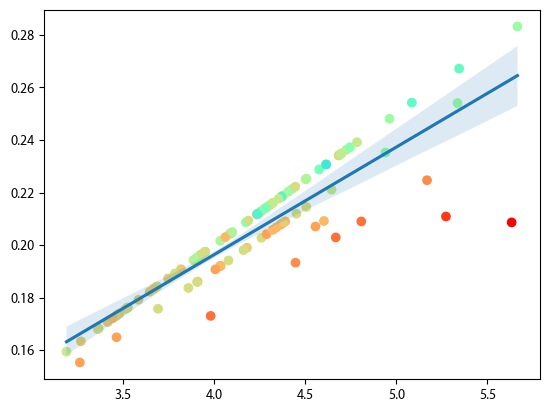

In [7]:
sns.regplot(x=dists_fastdtw, y=dists_claude, scatter_kws={'color': plt.cm.rainbow(np.array(rec_lens) / np.max(rec_lens))})




In [9]:
from scipy.stats import pearsonr

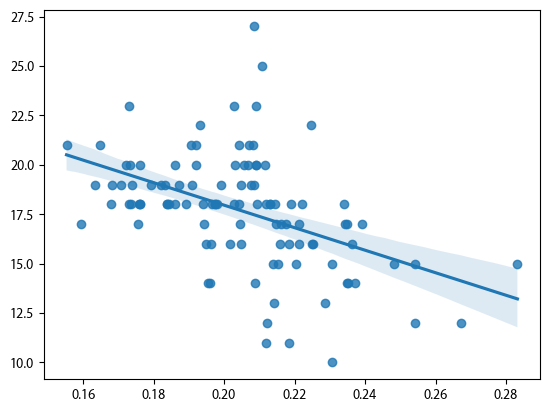

PearsonRResult(statistic=np.float64(-0.46471252018378073), pvalue=np.float64(5.21258410027249e-07))


In [10]:
sns.regplot(x=dists_claude, y=rec_lens)
plt.show()
print(pearsonr(dists_claude, rec_lens))

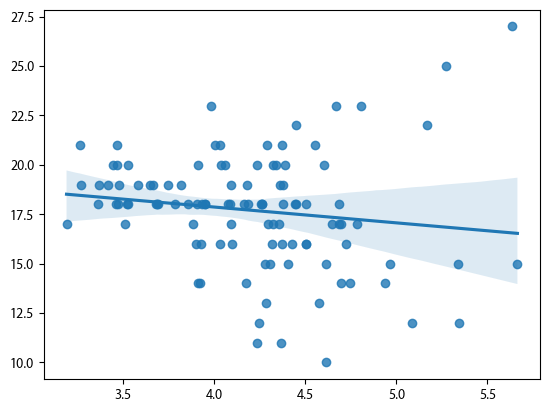

PearsonRResult(statistic=np.float64(-0.1441214974118203), pvalue=np.float64(0.14049916132356122))


In [11]:
sns.regplot(x=dists_fastdtw, y=rec_lens)
plt.show()
print(pearsonr(dists_fastdtw, rec_lens))

In [50]:
(cosine

<function scipy.spatial.distance.cosine(u, v, w=None)>

In [98]:
def _cos_cost(A, B):                      # A:(n,d) B:(m,d) -> (n,m) in [0,2]
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return 1.0 - A @ B.T


def dtw(A, B):
    """Monotonic DTW. Returns (avg cost along path, path)."""
    C = cdist(A, B, metric='cosine')
    n, m = C.shape
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            D[i, j] = C[i - 1,j - 1] + min(D[i - 1, j - 1], D[i - 1, j], D[i, j - 1])
    i, j, path = n, m, []
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        mv = min(D[i - 1, j - 1], D[i - 1, j], D[i, j - 1])
        if D[i - 1,j - 1] == mv: 
            i, j = i - 1, j - 1
        elif D[i - 1, j] == mv: 
            i = i - 1
        else:
            j = j - 1
    return D[n, m] / len(path), path[::-1]


def lcss(A, B, eps):
    """Order-preserving longest common subsequence within cosine-dist eps.
    Returns matched fraction in [0,1] (normalized by the shorter sequence)."""
    close = _cos_cost(A, B) < eps; n, m = close.shape
    L = np.zeros((n+1, m+1), dtype=int)
    for i in range(1, n+1):
        for j in range(1, m+1):
            L[i,j] = L[i-1,j-1] + 1 if close[i-1,j-1] else max(L[i-1,j], L[i,j-1])
    return L[n,m] / min(n, m)   # similarity; for dissim use 1 - this

In [21]:
events_immediate = {f'P{p.sub_n}': p.events['atlep1'] for p in participants}
events_delayed = {f'P{p.sub_n}': p.events['delayed'] for p in participants}
episode_events = atlep1.events

pids = list(events_delayed.keys())

## DTW version

### Claude mean-cost DTW

In [35]:
# (1) The comparison you described: own-immediate vs episode
d_self = np.array([dtw(events_delayed[p], events_immediate[p])[0] for p in pids])
d_epi  = np.array([dtw(events_delayed[p], episode_events)[0] for p in pids])
print(f'mean of d_self: {d_self.mean():.3f}')
print(f'mean of d_epi: {d_epi.mean():.3f}')
print("self vs episode:", wilcoxon(d_self, d_epi))

# (2) The control that defeats the register confound:
#     own-immediate vs OTHER participants' immediate recalls
own_beats_other = []
for p in pids:
    dp = {q: dtw(events_delayed[p], events_immediate[q])[0] for q in pids}
    others = np.array([dp[q] for q in pids if q != p])
    own_beats_other.append(np.mean(dp[p] < others))  # 1.0 = own is closest
own_beats_other = np.array(own_beats_other)
print(f'mean of own_beats_other: {own_beats_other.mean():.3f}')
print("own-immediate vs others (vs chance 0.5):", wilcoxon(own_beats_other - 0.5))

mean of d_self: 0.145
mean of d_epi: 0.213
self vs episode: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(2.3864847525460643e-10))
mean of own_beats_other: 0.999
own-immediate vs others (vs chance 0.5): WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.2506343175088189e-12))


In [36]:
# (1) The comparison you described: own-immediate vs episode
d_self = np.array([dtw(events_delayed[p] - events_delayed[p].mean(0), events_immediate[p] - events_immediate[p].mean(0))[0] for p in pids])
d_epi  = np.array([dtw(events_delayed[p] - events_delayed[p].mean(0), episode_events - episode_events.mean(0))[0] for p in pids])
print(f'mean of d_self: {d_self.mean():.3f}')
print(f'mean of d_epi: {d_epi.mean():.3f}')
print("self vs episode:", wilcoxon(d_self, d_epi))

# (2) The control that defeats the register confound:
#     own-immediate vs OTHER participants' immediate recalls
own_beats_other = []
for p in pids:
    dp = {q: dtw(events_delayed[p] - events_delayed[p].mean(0), events_immediate[q] - events_immediate[q].mean(0))[0] for q in pids}
    others = np.array([dp[q] for q in pids if q != p])
    own_beats_other.append(np.mean(dp[p] < others))  # 1.0 = own is closest
own_beats_other = np.array(own_beats_other)
print(f'mean of own_beats_other: {own_beats_other.mean():.3f}')
print("own-immediate vs others (vs chance 0.5):", wilcoxon(own_beats_other - 0.5))

mean of d_self: 0.473
mean of d_epi: 0.647
self vs episode: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(2.3864847525460643e-10))
mean of own_beats_other: 0.997
own-immediate vs others (vs chance 0.5): WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.2510297117563927e-12))


### fastdtw sum-cost DTW

In [37]:
# (1) The comparison you described: own-immediate vs episode
d_self = np.array([fastdtw(events_delayed[p], events_immediate[p])[0] for p in pids])
d_epi  = np.array([fastdtw(events_delayed[p], episode_events)[0] for p in pids])
print(f'mean of d_self: {d_self.mean():.3f}')
print(f'mean of d_epi: {d_epi.mean():.3f}')
print("self vs episode:", wilcoxon(d_self, d_epi))

# (2) The control that defeats the register confound:
#     own-immediate vs OTHER participants' immediate recalls
own_beats_other = []
for p in pids:
    dp = {q: fastdtw(events_delayed[p], events_immediate[q])[0] for q in pids}
    others = np.array([dp[q] for q in pids if q != p])
    own_beats_other.append(np.mean(dp[p] < others))  # 1.0 = own is closest
own_beats_other = np.array(own_beats_other)
print(f'mean of own_beats_other: {own_beats_other.mean():.3f}')
print("own-immediate vs others (vs chance 0.5):", wilcoxon(own_beats_other - 0.5))

mean of d_self: 207.621
mean of d_epi: 261.907
self vs episode: WilcoxonResult(statistic=np.float64(11.0), pvalue=np.float64(4.4669036835874424e-10))
mean of own_beats_other: 0.927
own-immediate vs others (vs chance 0.5): WilcoxonResult(statistic=np.float64(9.0), pvalue=np.float64(1.415166810780683e-10))


In [38]:
# (1) The comparison you described: own-immediate vs episode
d_self = np.array([fastdtw(events_delayed[p] - events_delayed[p].mean(0), events_immediate[p] - events_immediate[p].mean(0))[0] for p in pids])
d_epi  = np.array([fastdtw(events_delayed[p] - events_delayed[p].mean(0), episode_events - episode_events.mean(0))[0] for p in pids])
print(f'mean of d_self: {d_self.mean():.3f}')
print(f'mean of d_epi: {d_epi.mean():.3f}')
print("self vs episode:", wilcoxon(d_self, d_epi))

# (2) The control that defeats the register confound:
#     own-immediate vs OTHER participants' immediate recalls
own_beats_other = []
for p in pids:
    dp = {q: fastdtw(events_delayed[p] - events_delayed[p].mean(0), events_immediate[q] - events_immediate[q].mean(0))[0] for q in pids}
    others = np.array([dp[q] for q in pids if q != p])
    own_beats_other.append(np.mean(dp[p] < others))  # 1.0 = own is closest
own_beats_other = np.array(own_beats_other)
print(f'mean of own_beats_other: {own_beats_other.mean():.3f}')
print("own-immediate vs others (vs chance 0.5):", wilcoxon(own_beats_other - 0.5))

mean of d_self: 192.076
mean of d_epi: 220.456
self vs episode: WilcoxonResult(statistic=np.float64(116.0), pvalue=np.float64(1.1130223885980369e-07))
mean of own_beats_other: 0.905
own-immediate vs others (vs chance 0.5): WilcoxonResult(statistic=np.float64(20.5), pvalue=np.float64(4.940153172184847e-10))


## LCSS version

In [43]:
for epsilon in np.arange(0.1, 1.0000001, 0.1).round(2):
    print(f'epsilon={epsilon.item()}')
    # (1) The comparison you described: own-immediate vs episode
    d_self = np.array([1 - lcss(events_delayed[p], events_immediate[p], eps=epsilon) for p in pids])
    d_epi  = np.array([1 - lcss(events_delayed[p], episode_events, eps=epsilon) for p in pids])
    T, p = wilcoxon(d_self, d_epi)
    T, p = T.item(), p.item()
    print(f'mean of d_self: {d_self.mean():.3f}')
    print(f'mean of d_epi: {d_epi.mean():.3f}')
    print(f"self vs episode: {T = }, {p = :.2e}")

    # (2) The control that defeats the register confound:
    #     own-immediate vs OTHER participants' immediate recalls
    own_beats_other = []
    for p in pids:
        dp = {q: 1 - lcss(events_delayed[p], events_immediate[q], eps=epsilon) for q in pids}
        others = np.array([dp[q] for q in pids if q != p])
        own_beats_other.append(np.mean(dp[p] < others))  # 1.0 = own is closest
    own_beats_other = np.array(own_beats_other)
    T, p = wilcoxon(own_beats_other - 0.5)
    T, p = T.item(), p.item()
    print(f'mean of own_beats_other: {own_beats_other.mean():.3f}')
    print(f"own-immediate vs others (vs chance 0.5): {T = }, {p = :.2e}")
    print('==================')

epsilon=0.1
mean of d_self: 0.690
mean of d_epi: 0.994
self vs episode: T = 0.0, p = 5.11e-10
mean of own_beats_other: 0.952
own-immediate vs others (vs chance 0.5): T = 65.0, p = 8.12e-10
epsilon=0.2
mean of d_self: 0.121
mean of d_epi: 0.493
self vs episode: T = 0.0, p = 2.38e-10
mean of own_beats_other: 0.968
own-immediate vs others (vs chance 0.5): T = 0.0, p = 8.19e-11
epsilon=0.3
mean of d_self: 0.016
mean of d_epi: 0.041
self vs episode: T = 58.5, p = 2.94e-03
mean of own_beats_other: 0.526
own-immediate vs others (vs chance 0.5): T = 580.5, p = 4.39e-01
epsilon=0.4
mean of d_self: 0.000
mean of d_epi: 0.001
self vs episode: T = 0.0, p = 3.17e-01
mean of own_beats_other: 0.043
own-immediate vs others (vs chance 0.5): T = 0.0, p = 1.97e-10
epsilon=0.5
mean of d_self: 0.000
mean of d_epi: 0.000
self vs episode: T = 0.0, p = nan
mean of own_beats_other: 0.000
own-immediate vs others (vs chance 0.5): T = 0.0, p = 3.34e-13
epsilon=0.6
mean of d_self: 0.000
mean of d_epi: 0.000
self v

In [45]:
for epsilon in np.arange(0.1, 1.0000001, 0.1).round(2):
    print(f'epsilon={epsilon.item()}')
    # (1) The comparison you described: own-immediate vs episode
    d_self = np.array([1 - lcss(events_delayed[p] - events_delayed[p].mean(0), events_immediate[p] - events_immediate[p].mean(0), eps=epsilon) for p in pids])
    d_epi  = np.array([1 - lcss(events_delayed[p] - events_delayed[p].mean(0), episode_events - episode_events.mean(0), eps=epsilon) for p in pids])
    T, p = wilcoxon(d_self, d_epi)
    T, p = T.item(), p.item()
    print(f'mean of d_self: {d_self.mean():.3f}')
    print(f'mean of d_epi: {d_epi.mean():.3f}')
    print(f"self vs episode: {T = }, {p = :.2e}")

    # (2) The control that defeats the register confound:
    #     own-immediate vs OTHER participants' immediate recalls
    own_beats_other = []
    for p in pids:
        dp = {q: 1 - lcss(events_delayed[p] - events_delayed[p].mean(0), events_immediate[q] - events_immediate[q].mean(0), eps=epsilon) for q in pids}
        others = np.array([dp[q] for q in pids if q != p])
        own_beats_other.append(np.mean(dp[p] < others))  # 1.0 = own is closest
    own_beats_other = np.array(own_beats_other)
    T, p = wilcoxon(own_beats_other - 0.5)
    T, p = T.item(), p.item()
    print(f'mean of own_beats_other: {own_beats_other.mean():.3f}')
    print(f"own-immediate vs others (vs chance 0.5): {T = }, {p = :.2e}")
    print('==================')

epsilon=0.1
mean of d_self: 0.999
mean of d_epi: 1.000
self vs episode: T = 0.0, p = 3.17e-01
mean of own_beats_other: 0.019
own-immediate vs others (vs chance 0.5): T = 27.0, p = 2.46e-12
epsilon=0.2
mean of d_self: 0.959
mean of d_epi: 1.000
self vs episode: T = 0.0, p = 8.52e-05
mean of own_beats_other: 0.376
own-immediate vs others (vs chance 0.5): T = 474.0, p = 1.74e-02
epsilon=0.3
mean of d_self: 0.758
mean of d_epi: 0.997
self vs episode: T = 1.0, p = 2.54e-09
mean of own_beats_other: 0.881
own-immediate vs others (vs chance 0.5): T = 174.0, p = 9.66e-08
epsilon=0.4
mean of d_self: 0.510
mean of d_epi: 0.951
self vs episode: T = 0.0, p = 5.13e-10
mean of own_beats_other: 0.962
own-immediate vs others (vs chance 0.5): T = 56.0, p = 4.23e-11
epsilon=0.5
mean of d_self: 0.268
mean of d_epi: 0.778
self vs episode: T = 0.0, p = 2.39e-10
mean of own_beats_other: 0.997
own-immediate vs others (vs chance 0.5): T = 0.0, p = 1.83e-12
epsilon=0.6
mean of d_self: 0.144
mean of d_epi: 0.450

In [49]:
p = pids[0]
{q: 1 - lcss(events_delayed[p] - events_delayed[p].mean(0), 
             events_immediate[q] - events_immediate[q].mean(0), 
             eps=epsilon) 
 for q in pids}




{'P1': np.float64(1.0),
 'P2': np.float64(1.0),
 'P3': np.float64(0.8947368421052632),
 'P4': np.float64(0.8947368421052632),
 'P5': np.float64(0.9444444444444444),
 'P6': np.float64(0.9444444444444444),
 'P7': np.float64(1.0),
 'P8': np.float64(0.8947368421052632),
 'P9': np.float64(1.0),
 'P10': np.float64(1.0),
 'P11': np.float64(0.8888888888888888),
 'P12': np.float64(1.0),
 'P13': np.float64(0.9375),
 'P14': np.float64(0.9473684210526315),
 'P15': np.float64(1.0),
 'P16': np.float64(1.0),
 'P17': np.float64(1.0),
 'P18': np.float64(1.0),
 'P19': np.float64(0.9473684210526315),
 'P20': np.float64(0.9444444444444444),
 'P21': np.float64(0.9444444444444444),
 'P22': np.float64(1.0),
 'P23': np.float64(0.9444444444444444),
 'P24': np.float64(0.9473684210526315),
 'P25': np.float64(0.9444444444444444),
 'P26': np.float64(0.9285714285714286),
 'P27': np.float64(0.8947368421052632),
 'P28': np.float64(0.9444444444444444),
 'P29': np.float64(1.0),
 'P30': np.float64(1.0),
 'P31': np.float

<Axes: ylabel='Count'>

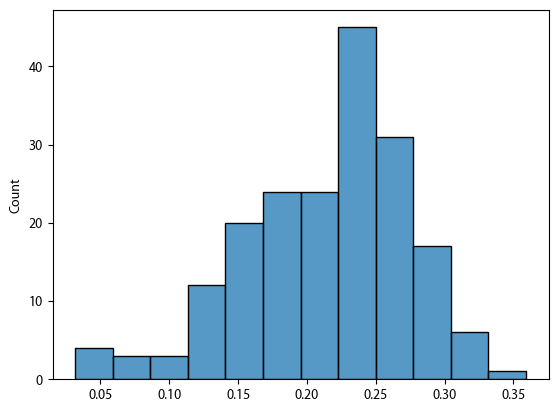

In [128]:
sns.histplot(pdist(atlep1.events, 'cosine'))

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])